In [23]:
from cfa import cfa_single_layer, performance_plot, RSC_graph
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker # for RSC function graph
import pandas as pd
import numpy as np
# import auroc 
from sklearn.metrics import roc_auc_score
from itertools import combinations

In [2]:
# use saved plot style to draw a better figure
plt.style.use('recovered_style.mplstyle') 

## Load eye movement data

In [3]:
# Load the dataset
df = pd.read_csv('ScoreFunctions-withRating.csv')

# map right to 0 and left to 1 for column Rating
df['Rating'] = df['Rating'].map({'Right': 0, 'Left': 1}) 
df.head(5)

,A,B,C,D,E,Rating
0,0.0,0.460124,0.428571,0.468178,0.463415,0
1,0.0,0.498609,0.571429,0.469353,0.512195,0
2,1.0,0.535394,0.628571,0.385390,0.463415,1
3,1.0,0.607883,0.828571,0.363728,0.585366,1
4,1.0,0.551005,0.600000,0.398489,0.365854,1


In [4]:
df1 = df[['A', 'B', 'C', 'D', 'E']]
y_true = df['Rating']
df1.head(2)

,A,B,C,D,E
0,0.0,0.460124,0.428571,0.468178,0.463415
1,0.0,0.498609,0.571429,0.469353,0.512195


## Some useful functions

In [12]:
def compute_auroc(df, y_true):
    auroc_scores = {}
    for col in df.columns:
        auroc = roc_auc_score(y_true, df[col])
        auroc_scores[col] = auroc
    auroc_scores_df = pd.DataFrame.from_dict(auroc_scores, orient='index', columns=['AUROC'])
    auroc_scores_df = auroc_scores_df.sort_values(by='AUROC', ascending=False)

    return auroc_scores_df

In [13]:
def normalization(df: pd.DataFrame) -> pd.DataFrame:    
    minv = df.min(axis = 0)
    maxv = df.max(axis = 0)
    denom = (maxv - minv).replace(0, np.nan)  # Avoid division by zero
    if denom.isna().any():
        print("At leaset one column of the data frame is constant!")

    scaled = (df - minv) / denom
    scaled = scaled.fillna(0.0)
    
    return scaled


def compute_cd_ds(df):
    # Step 1: Scale each column to [0,1] (min–max scaling)
    minv = df.min(axis = 0)
    maxv = df.max(axis = 0)
    denom = (maxv - minv).replace(0, np.nan)  # Avoid division by zero
    if denom.isna().any():
        print("At leaset one column of the data frame is constant!")

    scaled = (df - minv) / denom
    scaled = scaled.fillna(0.0)

    # Step 2: Sort each column descending independently, which is rank-score function
    df_1 = pd.DataFrame({
        c: scaled[c].sort_values(ascending=False).reset_index(drop=True)
        for c in scaled.columns
    })

    # Step 3: Compute CD for each pair (root mean squared difference)
    pairs = list(itertools.combinations(df_1.columns, 2))
    cds = []
    pair_labels = []
    for a, b in pairs:
        x = df_1[a].to_numpy()
        y = df_1[b].to_numpy()
        x_size = x.size
        if x_size == 1:
            x_size = 2 # avoid x_size -1 = 0
        cd = np.sqrt(np.sum( (x - y) ** 2 )/ (x_size - 1))
        cds.append(cd)
        pair_labels.append((a, b))  # tuple for easier filtering later for calcualting ds
    df_2 = pd.DataFrame({"CD": cds}, index=pd.MultiIndex.from_tuples(pair_labels, names=["Col1", "Col2"]))

    # Step 4: For each column, compute ds = average CD over all pairs containing it
    ds_vals = {}
    for col in df_1.columns:
        mask = (df_2.index.get_level_values(0) == col) | (df_2.index.get_level_values(1) == col)
        ds_vals[col] = df_2.loc[mask, "CD"].mean()
    df_3 = pd.DataFrame({"ds": pd.Series(ds_vals)})

    return df_1, df_2, df_3


def average_score_combination(df):
    scoring_sys = {}

    # Generate combinations of 2 to n columns (n-> number of columns in df)
    for r in range(2, 6):
        for cols in itertools.combinations(df.columns, r):
            combo_name = ''.join(cols)
            avg_scores = df[list(cols)].mean(axis=1)
            scoring_sys[combo_name] = avg_scores

    # Convert to DataFrame
    score_df = pd.DataFrame(scoring_sys, index=df.index)
    return score_df

def weighted_score_combination_by_ds(df):
    scoring_sys = {}

    # Generate combinations of 2 to (n+1) columns (n-> number of columns in df)
    for r in range(2, 6):
        for cols in itertools.combinations(df.columns, r):
            combo_name = ''.join(cols)
            df_subset = df[list(cols)]
            _, _, df_weights = compute_cd_ds(df_subset) # only need diversity strength
            weights = df_weights.loc[df_subset.columns, 'ds'] # weights is pd.Series here
            weights = weights/sum(weights)
            weighted_scores = df_subset.mul(weights, axis = 1).sum(axis = 1)
            scoring_sys[combo_name] = weighted_scores

    # Convert to DataFrame
    score_df = pd.DataFrame(scoring_sys, index=df.index)
    return score_df


In [14]:
def EAR(df: pd.DataFrame, reduction_method: str) -> pd.DataFrame:

    #------------- Expansion begin: input: five scoring systems (df, pd.DataFrame) ------------
    ASC_df = average_score_combination(df); WSCDS_df = weighted_score_combination_by_ds(df)
    ASC_df = ASC_df.add_suffix("_asc"); WSCDS_df = WSCDS_df.add_suffix("_wscds")
    SC_df = pd.concat([ASC_df, WSCDS_df], axis = 1) # 52 combination for reduction, no base models
    #------------- Expansion end: output: expanded scoring systems (SC_df, pd.DataFrame) --------

    SC_df_eval = pd.concat([df, SC_df], axis = 1) # 52 + 5 combinations for evaluation

    #------------- Reduction begin: input: expanded scoring systems (SC_df, pd.DataFrame) -------------
    ## 1. drop constant columns --> 2. remove duplicate columns --> 3. compute ds -->
    ## 4. select top five by ds --> 5. rename to A, B, C, D, E, etc.
    if SC_df.shape[0] > 1: # in case only has one row, all cols become constant
        const_cols = SC_df.columns[SC_df.nunique() <= 1] # drop constant columns
        SC_df = SC_df.drop(columns = const_cols)
    SC_df = SC_df.loc[:, ~SC_df.round(6).T.duplicated()] # remove duplicates, 6 digits for float precision

    if reduction_method == 'performance':
        red_perf = compute_performance(SC_df, y_true, perf_metric="precision@k", k = 200)
        reduce_five = red_perf.sort_values(ascending = False).head(5).index.tolist()
        new_five_ss = SC_df[reduce_five].copy() # avoid chained assignment warning
        
    elif reduction_method == 'diversity':
        _, _, ds = compute_cd_ds(SC_df)
        reduce_five = ds.sort_values(by = 'ds', ascending = False).index.to_list()[:5] # only use ds for reduction
        new_five_ss = SC_df[reduce_five].copy() # avoid chained assignment warning
        
    elif reduction_method == "hybrid":
        # get top 3 by performance 
        red_perf = compute_performance(SC_df, y_true, perf_metric="precision@k", k = 200)
        reduce_two = red_perf.sort_values(ascending = False).head(3).index.tolist()
        # get top 5 by diversity and remove any overlap with performance-selected ones
        _, _, ds = compute_cd_ds(SC_df)
        reduce_five = ds.sort_values(by = 'ds', ascending = False).index.to_list()[:5] # only use ds for reduction
        reduce_five = [x for x in reduce_five if x not in reduce_two] # remove any overlap
        # get top 3 by diversity 
        reduce_final_five = reduce_two + reduce_five[:2] # combine performance-selected and diversity-selected
        new_five_ss = SC_df[reduce_final_five].copy() # avoid chained assignment

    
    new_five_ss.columns = ['A', 'B', 'C', 'D', 'E']
    #------------- Reduction end: output: reduced five scoring systems (new_five_ss, pd.DataFrame) ------------ 

    return SC_df_eval, new_five_ss

In [15]:
# score combination: ASC + WSCDS
def score_combination(df):
    SC = {}
    for size in range(2, 6): # from 2 to the num of columns, df.shape[1]+1
        for cols in combinations(df.columns, size): # form groups
            df_subset = df[list(cols)]
            avg_scores = df_subset.mean(axis = 1) # average scores: ASC
            _, _, ds_df = compute_cd_ds(df_subset)
            w_series = ds_df['ds']; w_sum = w_series.sum() # in case sum of weight = 0
            if w_sum == 0: # if ds = 0, that means all columns are indentical, just choose the first column
                ds_scores = df_subset.iloc[:, 0] # no need to combine
            else:
                ds_scores = df_subset.mul(w_series, axis = 1).sum(axis = 1) / w_sum
            # save results
            combo_name1 = ''.join(cols) + '_asc'; combo_name2 = ''.join(cols) + '_wscds'
            SC[combo_name1] = avg_scores; SC[combo_name2] = ds_scores
            
    SC_df = pd.DataFrame(SC, index = df.index)
    return SC_df

# rank combination: ARC + WRCDS
def rank_combination(df):
    RC = {}
    # rank direction: ascending, 1 = smallest, here in MCF, mix score and rank combinations, to keep same direction
    ranks_df = df.rank(axis = 0, ascending = True, method = "average") 
    for size in range(2, 6):
        for cols in combinations(ranks_df.columns, size):
            df_subset_ranks = ranks_df[list(cols)]
            df_subset = df[list(cols)] # ds is computed from raw scores
            avg_scores = df_subset_ranks.mean(axis = 1) # average rank combination: ARC
            _, _, ds_df = compute_cd_ds(df_subset)
            w_series = ds_df['ds']; w_sum = w_series.sum()
            if w_sum == 0: # if ds = 0, that means all columns are indentical, just choose the first column
                ds_scores = df_subset_ranks.iloc[:, 0] # no need to combine  
            else:          
                # weight and rank direction should be consistent: ascending + raw weight; descending + inverted weight
                ds_scores = df_subset_ranks.mul(w_series, axis = 1).sum(axis = 1) / w_sum
            # save results
            combo_name1 = ''.join(cols) + '_arc'; combo_name2 = ''.join(cols) + '_wrcds'
            RC[combo_name1] = avg_scores; RC[combo_name2] = ds_scores
            
    RC_df = pd.DataFrame(RC, index = df.index)
    return RC_df

In [16]:
def EAR_full(df: pd.DataFrame) -> pd.DataFrame:

    #------------- Expansion begin: input: five scoring systems (df, pd.DataFrame) ------------
    SC_df = score_combination(df); RC_df = rank_combination(df)
    SC_RC = pd.concat([SC_df, RC_df], axis = 1) # 104 combination for reduction, no base models
    #------------- Expansion end: output: expanded scoring systems (SC_RC, pd.DataFrame) --------

    SC_RC_df = pd.concat([df, SC_df, RC_df], axis = 1) # 104 + 5 combinations for evaluation

    #------------- Reduction begin: input: expanded scoring systems (SC_RC, pd.DataFrame) -------------
    ## 1. drop constant columns --> 2. remove duplicate columns --> 3. compute ds -->
    ## 4. select top five by ds --> 5. normalize rank combinations if any -->
    ## 6. rename to A, B, C, D, E, etc.
    if SC_RC.shape[0] > 1: # in case only has one row, all cols become constant
        const_cols = SC_RC.columns[SC_RC.nunique() <= 1] # drop constant columns
        SC_RC = SC_RC.drop(columns = const_cols)
    SC_RC = SC_RC.loc[:, ~SC_RC.round(6).T.duplicated()] # remove duplicates

    _, _, ds = compute_cd_ds(SC_RC)
    reduce_five = ds.sort_values(by = 'ds', ascending = False).index.to_list()[:5] # only use ds for reduction
    new_five_ss = SC_RC[reduce_five].copy() # avoid chained assignment warning
    # check if it contains any rank combination. If so, we need to normalize to [0, 1]
    mask = new_five_ss.columns.str.contains(r"arc|wrcds", regex = True) # logic: True or False
    cols_from_RC= new_five_ss[ new_five_ss.columns[mask] ] 
    if cols_from_RC.shape[1] > 0:
        new_five_ss[ cols_from_RC.columns ] = normalization(cols_from_RC)
    # after normalization, need to rename the columns to A, B, C, E, etc.
    new_five_ss.columns = ['A', 'B', 'C', 'D', 'E']
    #------------- Reduction end: output: reduced five scoring systems (new_five_ss, pd.DataFrame) ------------ 

    return SC_RC_df, new_five_ss

In [17]:
def change_format_for_plot(perf_dict, include_scores=True, include_ranks=True):
    
    perf_series = pd.Series(perf_dict)
    # single-letter rows
    single = perf_series[perf_series.index.str.fullmatch(r"[A-Z]")].copy() 

    # score rows
    if include_scores:
        asc = perf_series[perf_series.index.str.endswith("_asc")].copy()
        asc.index = asc.index.str.replace(r"_asc$", "", regex=True)
        
        wscds = perf_series[perf_series.index.str.endswith("_wscds")].copy()
        wscds.index = wscds.index.str.replace(r"_wscds$", "", regex=True)

    # rank rows
    if include_ranks:
        arc = perf_series[perf_series.index.str.endswith("_arc")].copy()
        arc.index = arc.index.str.replace(r"_arc$", "", regex=True)
        
        wrcds = perf_series[perf_series.index.str.endswith("_wrcds")].copy()
        wrcds.index = wrcds.index.str.replace(r"_wrcds$", "", regex=True)


    # stack vertically: single letters first, then suffix rows
    if include_scores:
        col_asc = pd.concat([single, asc])
        col_wscds = pd.concat([single, wscds])
        df = pd.concat([col_asc, col_wscds],axis=1)
        df.columns = ["asc", "wscds"]
    if include_scores and include_ranks:
        col_asc = pd.concat([single, asc])
        col_wscds = pd.concat([single, wscds])
        col_arc = pd.concat([single, arc])
        col_wrcds = pd.concat([single, wrcds])
        df = pd.concat([col_asc, col_wscds, col_arc, col_wrcds],axis=1)
        df.columns = ["asc", "wscds", "arc", "wrcds"]
    return df

## Training ML models

In [ ]:
from sklearn.model_selection import train_test_split

# -----------------------------
# 1. Load  eye movement dataset
# -----------------------------

# Features and target
X = df1.copy()
y = y_true.copy()

# -----------------------------
# 2. 70:30 stratified split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain label counts:")
print(y_train.value_counts())
print("\nTest label counts:")
print(y_test.value_counts())

Train shape: (504, 5)
Test shape: (216, 5)

Train label counts:
Rating
0    254
1    250
Name: count, dtype: int64

Test label counts:
Rating
0    109
1    107
Name: count, dtype: int64


In [ ]:
# -----------------------------
# 3. Define models
# -----------------------------
# SVM, RF, XGBoost, AdaBoost, KNN
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import ( accuracy_score, precision_score, recall_score, f1_score, roc_auc_score )

models = {
    "SVM": Pipeline([
        ("model", SVC(probability=True, random_state=42))
    ]),
    
    "RandomForest": Pipeline([
        ("model", RandomForestClassifier(random_state=42))
    ]),
    
    "XGBoost": Pipeline([
        ("model", XGBClassifier(
            random_state=42,
            eval_metric="logloss"
        ))
    ]),
    "AdaBoost": Pipeline([
        ("model", AdaBoostClassifier(random_state=42))
    ]),
    
    "KNN": Pipeline([
        ("model", KNeighborsClassifier())
    ])
}

# -----------------------------
# 4. Train and evaluate
# -----------------------------
results = []
pred_probs = pd.DataFrame(index=X_test.index)

for name, clf in models.items():
    print(f"\nTraining {name}...")
    clf.fit(X_train, y_train)
    
    # predicted labels
    y_pred = clf.predict(X_test)
    
    # predicted probabilities for positive class
    y_prob = clf.predict_proba(X_test)[:, 1]
    pred_probs[name] = y_prob
    
    # metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_prob)
    
    results.append({
        "Model": name, "Accuracy": acc, "Precision": prec,
        "Recall": rec, "F1": f1, "AUC": auc
    })

# -----------------------------
# 5. Show results
# -----------------------------
results_df = pd.DataFrame(results).sort_values(by="AUC", ascending=False)
print("\nModel performance on test set:")
print(results_df)

# -----------------------------
# 6. Save predicted probabilities for CFA
# -----------------------------
pred_probs["true_label"] = y_test
pred_probs.to_csv("test_prob_eye_movement.csv", index=True)
# results_df.to_csv("model_results_70_30_split.csv", index=False)
print("\nSaved:")
print("- test_prob_eye_movement.csv")


Training SVM...

Training RandomForest...

Training XGBoost...

Training AdaBoost...

Training KNN...

Model performance on test set:
          Model  Accuracy  Precision    Recall        F1       AUC
0           SVM  0.898148   0.876106  0.925234  0.900000  0.946669
3      AdaBoost  0.870370   0.862385  0.878505  0.870370  0.934794
1  RandomForest  0.888889   0.887850  0.887850  0.887850  0.934408
4           KNN  0.893519   0.896226  0.887850  0.892019  0.933250
2       XGBoost  0.879630   0.871560  0.887850  0.879630  0.927206

Saved:
- test_prob_eye_movement.csv


In [7]:
pred_probs

,SVM,RandomForest,XGBoost,AdaBoost,KNN,true_label
317,0.584173,0.62,0.934225,0.573097,0.8,1
132,0.094927,0.17,0.241341,0.382688,0.2,0
419,0.878102,0.98,0.999005,0.696543,1.0,1
116,0.872071,0.90,0.988614,0.639157,1.0,1
639,0.877013,0.98,0.998539,0.711998,1.0,1
...,...,...,...,...,...,...
385,0.875339,1.00,0.999462,0.711998,1.0,1
417,0.089721,0.00,0.007831,0.339741,0.0,0
654,0.093911,0.33,0.137492,0.410540,0.2,0
191,0.874833,1.00,0.999524,0.711998,1.0,1


## Model Fusion

In [10]:
pred = pd.read_csv("test_prob_eye_movement.csv", index_col=0)
pred.head(3)

,SVM,RandomForest,XGBoost,AdaBoost,KNN,true_label
317,0.584173,0.62,0.934225,0.573097,0.8,1
132,0.094927,0.17,0.241341,0.382688,0.2,0
419,0.878102,0.98,0.999005,0.696543,1.0,1


In [11]:
df2 = pred.iloc[:, :-1]
y_tr2 = pred["true_label"]
df2.columns = ['A', 'B', 'C', 'D', 'E']
df2.head(3)

,A,B,C,D,E
317,0.584173,0.62,0.934225,0.573097,0.8
132,0.094927,0.17,0.241341,0.382688,0.2
419,0.878102,0.98,0.999005,0.696543,1.0


In [18]:
compute_auroc(df2, y_tr2)

,AUROC
A,0.946669
D,0.934794
B,0.934408
E,0.933250
C,0.927206


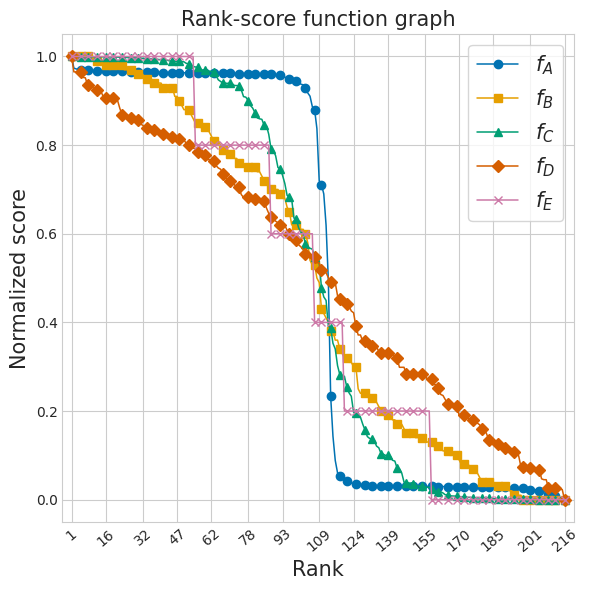

In [19]:
RSC_graph(df2)

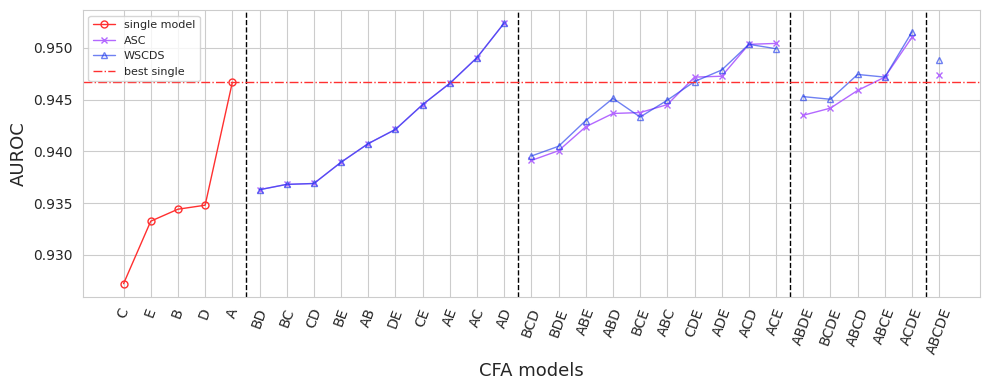

Best single: 0.9467
Best combination: 0.9524


In [20]:
ss_1 = df2.copy() # scoring system for layer 1

#----------- Layer 1 --------------------------------------
fusion_1, ss_2 = EAR(ss_1, reduction_method = 'diversity')
y_true = y_tr2.copy() # avoid chained assignment warning
auroc_df = compute_auroc(fusion_1, y_true)

# convert auroc_scores_df to dict
auroc_scores_dict = auroc_df['AUROC'].to_dict()

new1 = change_format_for_plot(auroc_scores_dict)
new1 = new1[['asc', 'wscds']]

# performance plot for layer 1
_ = performance_plot(new1, sort_col="asc", draw_cols=("asc", "wscds"),
    ylabel = "AUROC"
    )

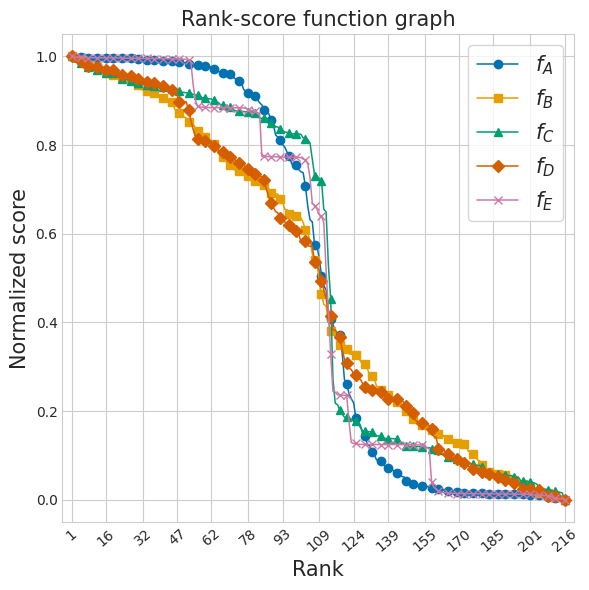

In [21]:
RSC_graph(ss_2)

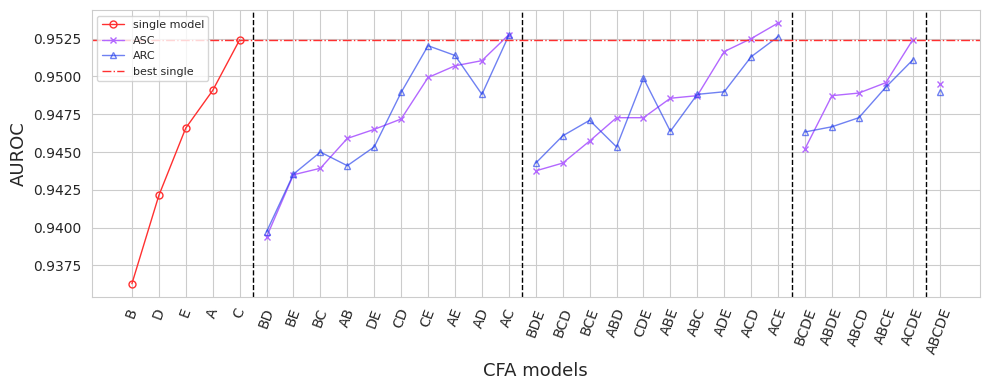

Best single: 0.9524
Best combination: 0.9535


In [24]:
#----------- Layer 2 --------------------------------------
fusion_2, ss_3 = EAR_full(ss_2)

# compute auroc for fusion_2
auroc_df = compute_auroc(fusion_2, y_true)

# convert auroc_scores_df to dict
auroc_scores_dict = auroc_df['AUROC'].to_dict()
# convert to format for plotting
new2 = change_format_for_plot(auroc_scores_dict)

# performance plot for layer 2
_ = performance_plot(new2, sort_col="asc", draw_cols=("asc", "arc"),
    ylabel = "AUROC"
    )

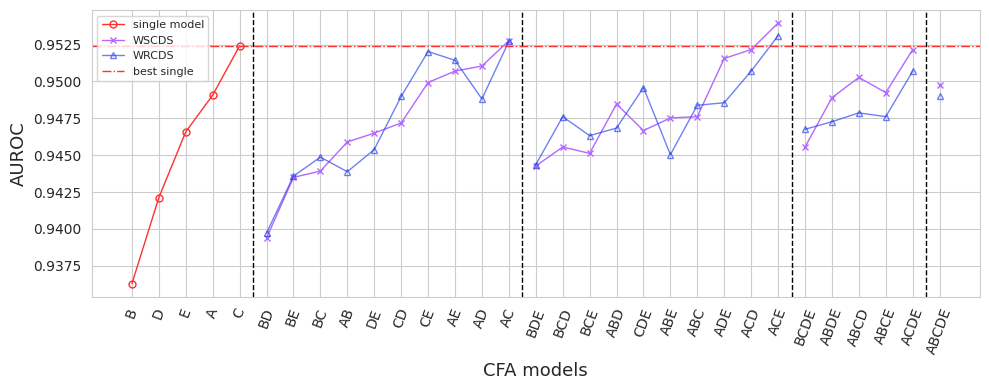

Best single: 0.9524
Best combination: 0.9540


In [25]:
_ = performance_plot(new2, sort_col="asc", draw_cols=("wscds", "wrcds"),
    ylabel = "AUROC"
    )

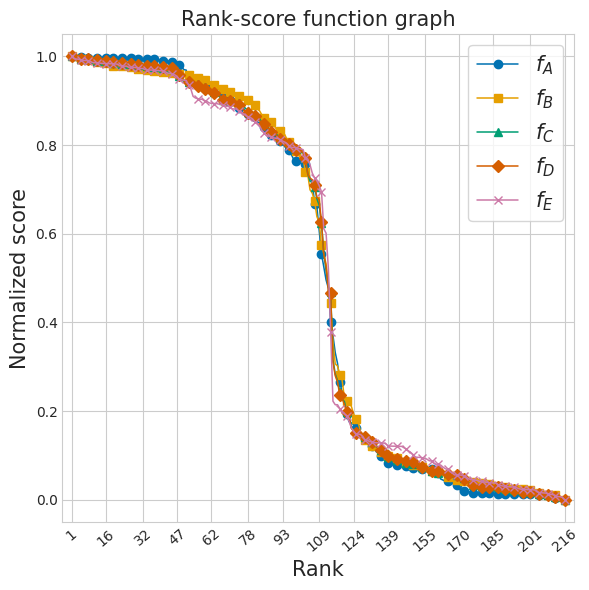

In [26]:
RSC_graph(ss_3)

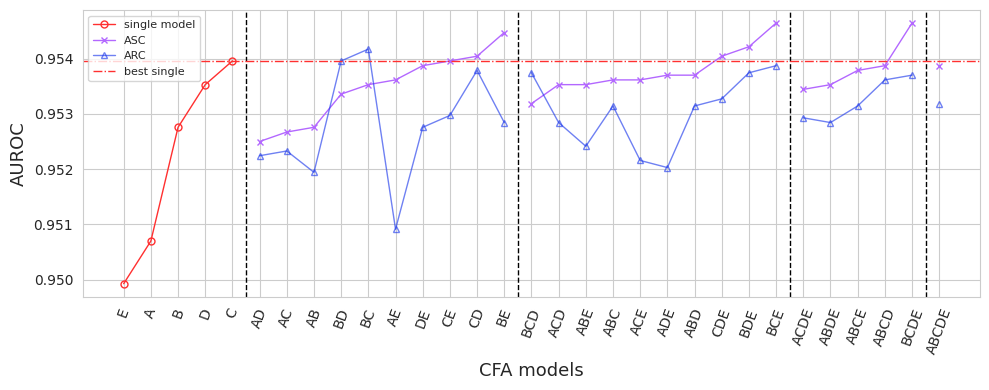

Best single: 0.9540
Best combination: 0.9546


In [27]:
#----------- Layer 3 --------------------------------------
fusion_3, ss_4 = EAR_full(ss_3)

# compute auroc for fusion_3
auroc_df = compute_auroc(fusion_3, y_true)

# convert auroc_scores_df to dict
auroc_scores_dict = auroc_df['AUROC'].to_dict()
# convert to format for plotting
new3 = change_format_for_plot(auroc_scores_dict)

# performance plot for layer 2
_ = performance_plot(new3, sort_col="asc", draw_cols=("asc", "arc"),
    ylabel = "AUROC"
    )

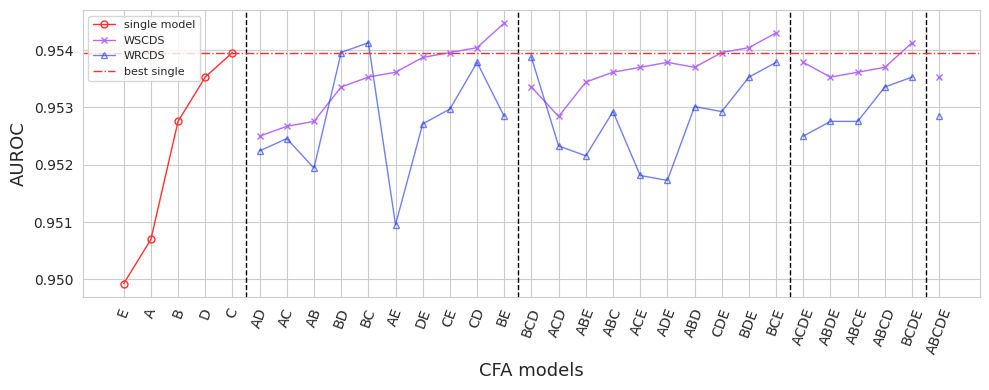

Best single: 0.9540
Best combination: 0.9545


In [28]:
_ = performance_plot(new3, sort_col="asc", draw_cols=("wscds", "wrcds"),
    ylabel = "AUROC"
    )